# Рекомендательная система фильмов


## Задание 1. Подготовка репозитория и данных
Датасет загружен в репозиторий. Ниже используем raw-ссылку на файл.

In [1]:
!pip install -q pandas numpy scikit-learn tensorflow matplotlib seaborn requests

## Задание 2. Подготовка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, io, pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Embedding, Flatten, Dot,
                                     Add, Dense, Dropout, Concatenate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

sns.set_style('whitegrid')
print('✅ Библиотеки загружены')

✅ Библиотеки загружены


In [3]:
url_data = 'https://raw.githubusercontent.com/danil4ik72/text-generation-lstm/refs/heads/main/ratings%20(2).txt'
response = requests.get(url_data)
response.encoding = 'utf-8'
df = pd.read_csv(io.StringIO(response.text), sep=';', comment='#', encoding='utf-8')
df['Рейтинг'] = df['Рейтинг'].astype(float)

print(f'Загружено оценок : {len(df)}')
print(f'Пользователей    : {df["User"].nunique()}')
print(f'Фильмов          : {df["Название"].nunique()}')
print(f'Жанров           : {df["Жанр"].nunique()}')
print(f'Рейтинг min/max  : {df["Рейтинг"].min()} / {df["Рейтинг"].max()}')
df.head()

Загружено оценок : 1034
Пользователей    : 40
Фильмов          : 66
Жанров           : 7
Рейтинг min/max  : 6.5 / 10.0


,User,Название,Жанр,Рейтинг
0,Иван,Тёмный рыцарь,боевик,9.4
1,Иван,Джон Уик,боевик,9.9
2,Иван,Mad Max: Fury Road,боевик,9.9
3,Иван,Матрица,боевик,9.0
4,Иван,Пятый элемент,боевик,8.1


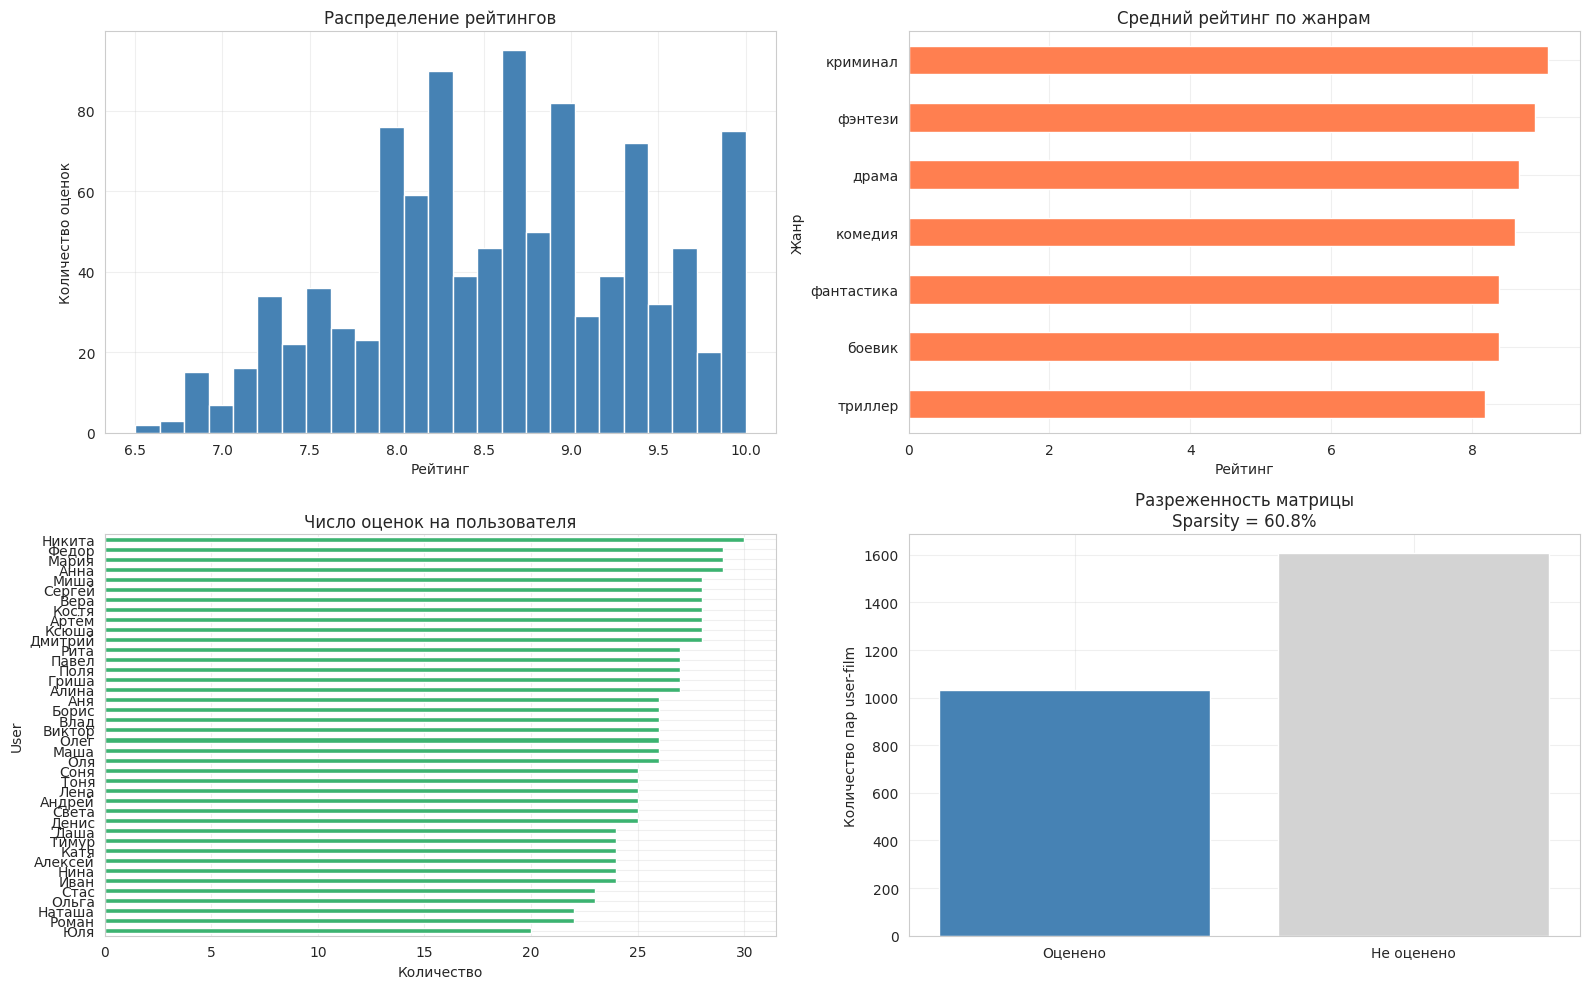

Разреженность матрицы: 60.8%
Высокая разреженность — именно для этого и нужна коллаборативная фильтрация:
модель восстанавливает пропущенные оценки на основе похожих пользователей.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(df['Рейтинг'], bins=25, color='steelblue', edgecolor='white')
axes[0,0].set_title('Распределение рейтингов')
axes[0,0].set_xlabel('Рейтинг')
axes[0,0].set_ylabel('Количество оценок')
axes[0,0].grid(True, alpha=0.3)

df.groupby('Жанр')['Рейтинг'].mean().sort_values().plot(
    kind='barh', ax=axes[0,1], color='coral', edgecolor='white')
axes[0,1].set_title('Средний рейтинг по жанрам')
axes[0,1].set_xlabel('Рейтинг')
axes[0,1].grid(True, alpha=0.3)

df.groupby('User')['Рейтинг'].count().sort_values().plot(
    kind='barh', ax=axes[1,0], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Число оценок на пользователя')
axes[1,0].set_xlabel('Количество')
axes[1,0].grid(True, alpha=0.3)

n_u = df['User'].nunique()
n_m = df['Название'].nunique()
total_possible = n_u * n_m
filled = len(df)
sparsity = 1 - filled / total_possible
axes[1,1].bar(['Оценено', 'Не оценено'],
              [filled, total_possible - filled],
              color=['steelblue', 'lightgray'], edgecolor='white')
axes[1,1].set_title(f'Разреженность матрицы\nSparsity = {sparsity:.1%}')
axes[1,1].set_ylabel('Количество пар user-film')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Разреженность матрицы: {sparsity:.1%}')
print('Высокая разреженность — именно для этого и нужна коллаборативная фильтрация:')
print('модель восстанавливает пропущенные оценки на основе похожих пользователей.')

In [5]:
user_enc  = LabelEncoder()
movie_enc = LabelEncoder()

df['user_id']  = user_enc.fit_transform(df['User'])
df['movie_id'] = movie_enc.fit_transform(df['Название'])

n_users  = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()

movie_titles = dict(enumerate(movie_enc.classes_))
movie_genres = df.groupby('movie_id')['Жанр'].first().to_dict()

print(f'Закодировано пользователей : {n_users}')
print(f'Закодировано фильмов       : {n_movies}')
print('Пример кодировки:', list(zip(user_enc.classes_[:3],
                                    user_enc.transform(user_enc.classes_[:3]))))

Закодировано пользователей : 40
Закодировано фильмов       : 66
Пример кодировки: [('Алексей', np.int64(0)), ('Алина', np.int64(1)), ('Андрей', np.int64(2))]


In [6]:
X = df[['user_id', 'movie_id']].values
y = df['Рейтинг'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

test_idx = np.where(
    np.isin(np.arange(len(df)),
            np.where(np.isin(df.index,
                             df.index[int(len(df)*0.8):]))[0])
)[0]
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
df_test_meta = df.iloc[idx_test][['User', 'Название', 'Жанр', 'Рейтинг']].copy()

print(f'Train: {len(X_train)} оценок (модель ОБУЧАЕТСЯ на них)')
print(f'Test : {len(X_test)}  оценок (модель НЕ видела, предскажем и сравним)')
print(f'\nПример тестовых строк (реальные оценки которые модель не видела):')
df_test_meta.head(8)

Train: 827 оценок (модель ОБУЧАЕТСЯ на них)
Test : 207  оценок (модель НЕ видела, предскажем и сравним)

Пример тестовых строк (реальные оценки которые модель не видела):


,User,Название,Жанр,Рейтинг
294,Мария,Город грехов,криминал,8.5
453,Рита,Один дома,комедия,8.2
638,Алина,Интерстеллар,фантастика,8.2
139,Стас,Побег из Шоушенка,драма,8.6
539,Юля,Прибытие,фантастика,8.1
365,Лена,1+1,драма,9.2
513,Катя,Миссия невыполнима,боевик,7.0
584,Поля,Пятый элемент,боевик,7.2


## Задание 3. Построение модели

In [7]:
K = 50

user_in  = Input(shape=(1,), name='user_input')
movie_in = Input(shape=(1,), name='movie_input')

u_emb = Flatten()(Embedding(n_users,  K, embeddings_regularizer=l2(1e-5), name='user_emb')(user_in))
m_emb = Flatten()(Embedding(n_movies, K, embeddings_regularizer=l2(1e-5), name='movie_emb')(movie_in))

dot = Dot(axes=1, name='dot_product')([u_emb, m_emb])

u_bias = Flatten()(Embedding(n_users,  1, name='user_bias')(user_in))
m_bias = Flatten()(Embedding(n_movies, 1, name='movie_bias')(movie_in))

pred  = Add(name='prediction')([dot, u_bias, m_bias])

model = Model([user_in, movie_in], pred)
model.compile(optimizer=Adam(0.001), loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 1, 50)     │      2,000 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_emb           │ (None, 1, 50)     │      3,300 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ user_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ movie_emb[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │         40 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_bias          │ (None, 1, 1)      │         66 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ movie_bias[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Add)    │ (None, 1)         │          0 │ dot_product[0][0… │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,406 (21.12 KB)

 Trainable params: 5,406 (21.12 KB)

 Non-trainable params: 0 (0.00 B)

## Задание 4. Обучение модели

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    [X_train[:, 0], X_train[:, 1]], y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 74.0272 - val_loss: 74.5024
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 73.5070 - val_loss: 74.0511
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 72.9974 - val_loss: 73.5918
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 72.4721 - val_loss: 73.1142
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 71.9177 - val_loss: 72.6023
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 71.3124 - val_loss: 72.0365
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70.6291 - val_loss: 71.3837
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 69.8388 - val_loss: 70.6164
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 68.9001 - val_loss: 69.6740
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 67.7711 - val_loss: 68.5263
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 66.4160 - val_loss: 67.1412
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

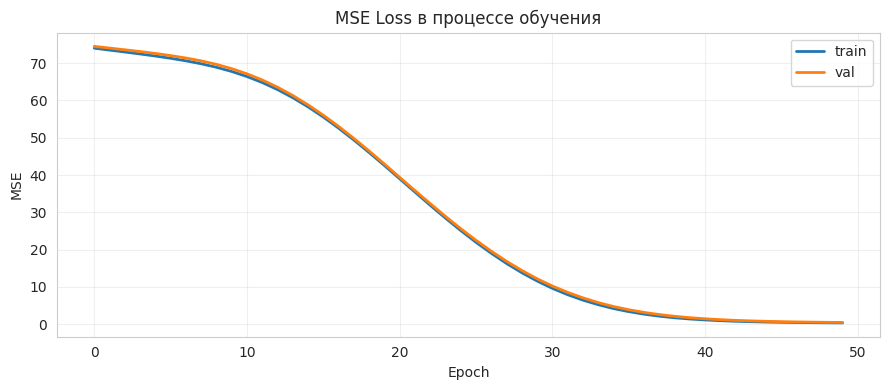

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='train', linewidth=2)
plt.plot(history.history['val_loss'], label='val',   linewidth=2)
plt.legend()
plt.title('MSE Loss в процессе обучения')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
preds_test = model.predict([X_test[:, 0], X_test[:, 1]], verbose=0).flatten()

rmse = np.sqrt(mean_squared_error(y_test, preds_test))
mae  = np.mean(np.abs(y_test - preds_test))
print(f'RMSE на тесте : {rmse:.3f}')
print(f'MAE  на тесте : {mae:.3f}')
print()
print('Интерпретация:')
print(f'  Рейтинги в диапазоне {y_test.min():.1f}–{y_test.max():.1f}')
print(f'  RMSE {rmse:.2f} = среднее отклонение предсказания от реальной оценки')
print(f'  Для шкалы 1–10 приемлемым считается RMSE < 1.0')

df_comparison = df_test_meta.copy().reset_index(drop=True)
df_comparison['Предсказано'] = np.round(preds_test, 2)
df_comparison['Ошибка']      = np.round(np.abs(preds_test - y_test), 2)
df_comparison = df_comparison.sort_values('User').reset_index(drop=True)
df_comparison.index += 1

print('\nДетальное сравнение (первые 20 строк):')
print(df_comparison.head(20).to_string())

RMSE на тесте : 0.831
MAE  на тесте : 0.660

Интерпретация:
  Рейтинги в диапазоне 6.7–10.0
  RMSE 0.83 = среднее отклонение предсказания от реальной оценки
  Для шкалы 1–10 приемлемым считается RMSE < 1.0

Детальное сравнение (первые 20 строк):
       User              Название        Жанр  Рейтинг  Предсказано  Ошибка
1   Алексей                   Тор     фэнтези      9.4         8.24    1.16
2   Алексей             Марсианин  фантастика      9.6         8.05    1.55
3   Алексей          Профессионал     триллер      9.1         7.82    1.28
4   Алексей       Список Шиндлера       драма      8.1         8.33    0.23
5   Алексей         Превосходство  фантастика      7.8         7.29    0.51
6   Алексей       Жизнь прекрасна       драма      7.0         7.33    0.33
7   Алексей               Матрица      боевик      8.3         7.58    0.72
8   Алексей                 Довод      боевик      9.6         8.55    1.05
9   Алексей    Место преступления    криминал      9.3         8.47   

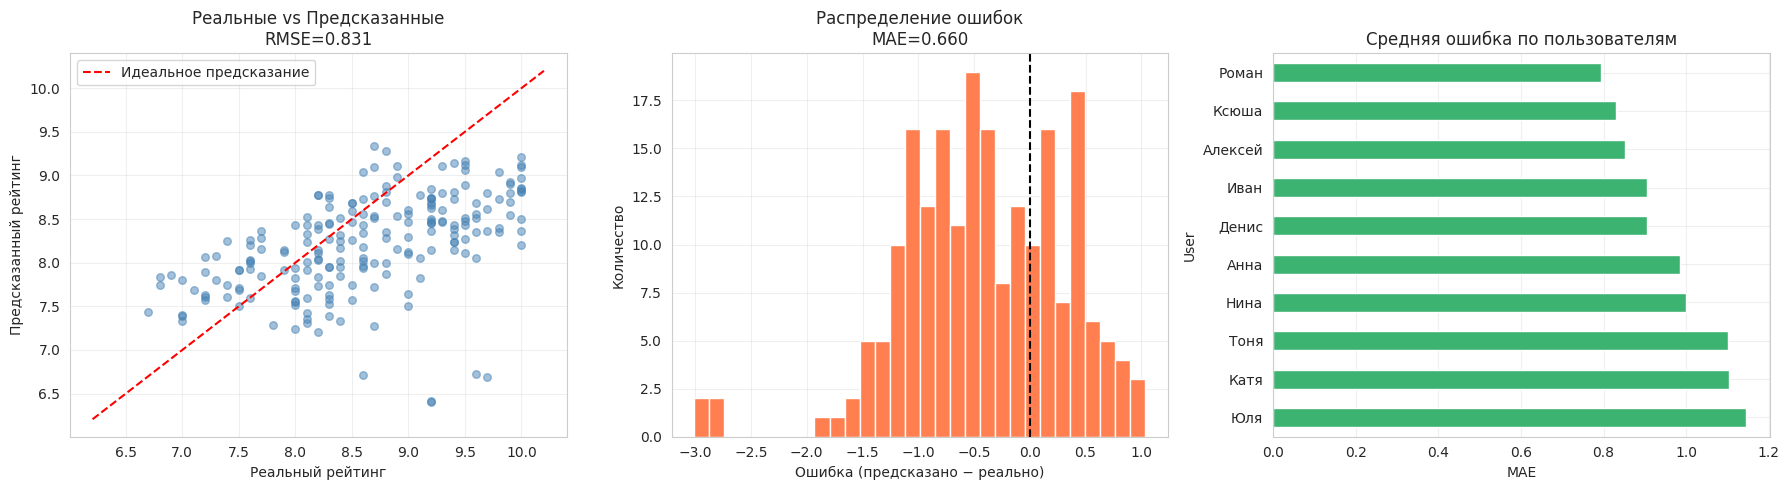

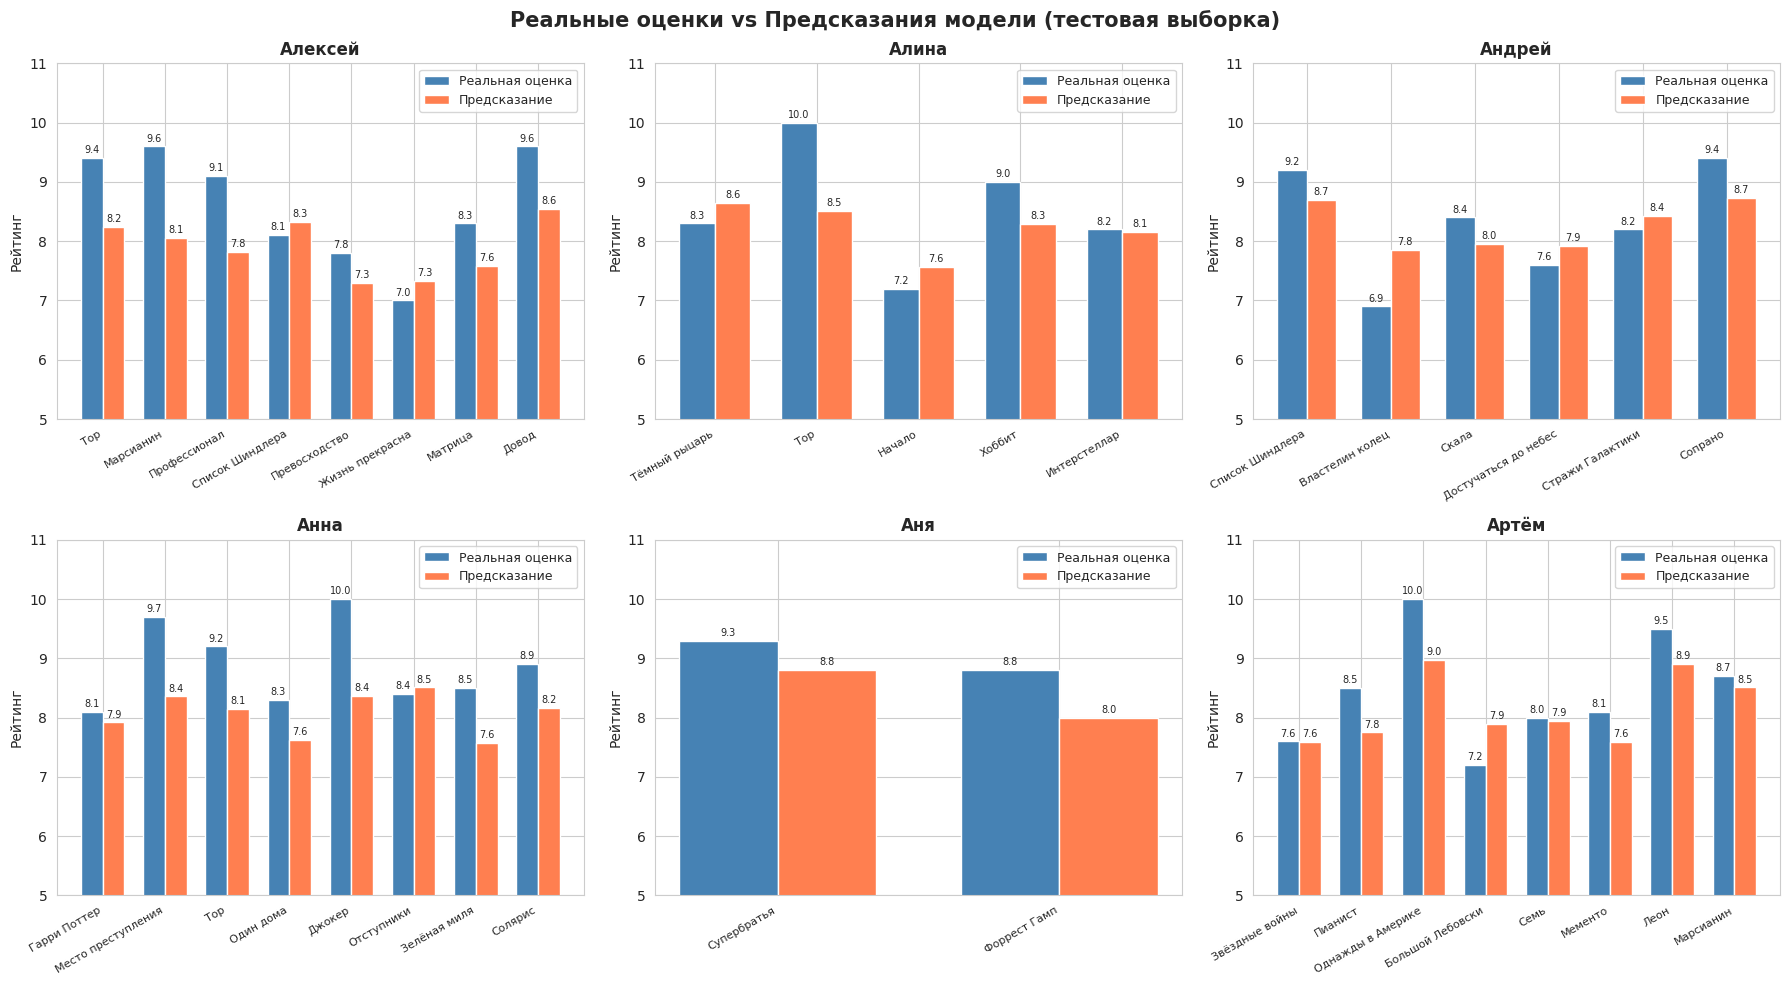

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, preds_test, alpha=0.5, color='steelblue', s=30)
lims = [min(y_test.min(), preds_test.min()) - 0.2,
        max(y_test.max(), preds_test.max()) + 0.2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Идеальное предсказание')
axes[0].set_xlabel('Реальный рейтинг')
axes[0].set_ylabel('Предсказанный рейтинг')
axes[0].set_title(f'Реальные vs Предсказанные\nRMSE={rmse:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = preds_test - y_test
axes[1].hist(errors, bins=30, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Ошибка (предсказано − реально)')
axes[1].set_ylabel('Количество')
axes[1].set_title(f'Распределение ошибок\nMAE={mae:.3f}')
axes[1].grid(True, alpha=0.3)

user_err = (
    df_comparison.groupby('User')['Ошибка']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
user_err.plot(kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Средняя ошибка по пользователям')
axes[2].set_xlabel('MAE')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

sample_users = df_comparison['User'].unique()[:6]
n_cols = 3
n_rows = int(np.ceil(len(sample_users) / n_cols))
fig, axes2 = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes2 = axes2.flatten()

for idx, user in enumerate(sample_users):
    udf = df_comparison[df_comparison['User'] == user].head(8)
    ax  = axes2[idx]
    x   = np.arange(len(udf))
    w   = 0.35
    b1  = ax.bar(x - w/2, udf['Рейтинг'],    w, label='Реальная оценка', color='steelblue')
    b2  = ax.bar(x + w/2, udf['Предсказано'], w, label='Предсказание',   color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(udf['Название'], rotation=30, ha='right', fontsize=8)
    ax.set_ylim(5, 11)
    ax.set_title(f'{user}', fontweight='bold')
    ax.set_ylabel('Рейтинг')
    ax.legend(fontsize=9)
    ax.bar_label(b1, fmt='%.1f', fontsize=7, padding=2)
    ax.bar_label(b2, fmt='%.1f', fontsize=7, padding=2)

for i in range(len(sample_users), len(axes2)):
    axes2[i].set_visible(False)

plt.suptitle('Реальные оценки vs Предсказания модели (тестовая выборка)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Задание 5. Функция рекомендаций

In [12]:
def recommend(user_name, genre=None, top_n=5):
    """
    Топ-N фильмов среди тех, которые пользователь ещё НЕ оценивал.
    Оценка предсказывается моделью на основе оценок похожих пользователей.

    Args:
        user_name : имя пользователя
        genre     : жанр-фильтр (None = все жанры)
        top_n     : количество рекомендаций
    """
    if user_name not in user_enc.classes_:
        print(f'Пользователь "{user_name}" не найден')
        return pd.DataFrame()

    uid      = user_enc.transform([user_name])[0]
    seen_ids = set(df[df['User'] == user_name]['movie_id'].tolist())

    candidate_ids = [
        mid for mid, g in movie_genres.items()
        if (genre is None or g == genre) and mid not in seen_ids
    ]

    if not candidate_ids:
        print(f'Нет новых фильмов для {user_name}'
              f'{" в жанре " + genre if genre else ""}')
        return pd.DataFrame()

    user_arr  = np.full(len(candidate_ids), uid)
    movie_arr = np.array(candidate_ids)
    scores    = model.predict([user_arr, movie_arr], verbose=0).flatten()

    top_idx = np.argsort(scores)[::-1][:top_n]
    result  = pd.DataFrame({
        'Фильм'                 : [movie_titles[candidate_ids[i]] for i in top_idx],
        'Жанр'                  : [movie_genres[candidate_ids[i]] for i in top_idx],
        'Предсказанный рейтинг' : [round(float(scores[i]), 2) for i in top_idx],
    })
    result.index += 1
    return result


print('✅ Функция recommend() определена')
print(f'Пользователей: {n_users} | Фильмов: {n_movies}')
print('Жанры:', sorted(set(movie_genres.values())))
print()
sample_user = user_enc.classes_[0]
seen_count   = len(df[df['User'] == sample_user])
unseen_count = n_movies - seen_count
print(f'Пример — {sample_user}: оценил {seen_count} фильмов, '
      f'не видел {unseen_count} фильмов → есть что рекомендовать ✅')

✅ Функция recommend() определена
Пользователей: 40 | Фильмов: 66
Жанры: ['боевик', 'драма', 'комедия', 'криминал', 'триллер', 'фантастика', 'фэнтези']

Пример — Алексей: оценил 24 фильмов, не видел 42 фильмов → есть что рекомендовать ✅


In [13]:
tests = [
    ('Иван',    'боевик'),
    ('Иван',    'фантастика'),
    ('Ольга',   'драма'),
    ('Ольга',   'комедия'),
    ('Дмитрий', 'криминал'),
    ('Дмитрий', 'триллер'),
]
for user, genre in tests:
    print(f'\n{"="*50}')
    print(f'👤 {user}  |  жанр: {genre}')
    print(recommend(user, genre=genre, top_n=5).to_string())


👤 Иван  |  жанр: боевик
                Фильм    Жанр  Предсказанный рейтинг
1               Довод  боевик                   8.69
2        Терминатор 2  боевик                   7.92
3               Скала  боевик                   7.84
4  Миссия невыполнима  боевик                   7.32

👤 Иван  |  жанр: фантастика
          Фильм        Жанр  Предсказанный рейтинг
1       Солярис  фантастика                   8.36
2     Марсианин  фантастика                   8.20
3  Интерстеллар  фантастика                   8.05

👤 Ольга  |  жанр: драма
                  Фильм   Жанр  Предсказанный рейтинг
1                Джокер  драма                   8.43
2       Жизнь прекрасна  драма                   7.77
3  Достучаться до небес  драма                   7.63

👤 Ольга  |  жанр: комедия
              Фильм     Жанр  Предсказанный рейтинг
1             Маска  комедия                   8.94
2       Супербратья  комедия                   8.60
3  Большой Лебовски  комедия                   7.68
4

## Задание 6. Сохранение модели и объектов

In [16]:
model.save('movie_recommender.keras')
with open('user_encoder.pickle',  'wb') as f: pickle.dump(user_enc,     f)
with open('movie_encoder.pickle', 'wb') as f: pickle.dump(movie_enc,    f)
with open('movie_titles.pickle',  'wb') as f: pickle.dump(movie_titles, f)
with open('movie_genres.pickle',  'wb') as f: pickle.dump(movie_genres, f)
print('✅ Модель сохранена: movie_recommender.keras')

✅ Модель сохранена: movie_recommender.keras


## Задание 7. Загрузка модели из репозитория и быстрые рекомендации

In [17]:
urls = {
    'movie_recommender.keras'  : 'https://raw.githubusercontent.com/danil4ik72/text-generation-lstm/refs/heads/main/movie_recommender.keras',
    'user_encoder.pickle'   : 'https://raw.githubusercontent.com/danil4ik72/text-generation-lstm/refs/heads/main/user_encoder.pickle',
    'movie_encoder.pickle'  : 'https://raw.githubusercontent.com/danil4ik72/text-generation-lstm/refs/heads/main/movie_encoder.pickle',
    'movie_titles.pickle'   : 'https://raw.githubusercontent.com/danil4ik72/text-generation-lstm/refs/heads/main/movie_titles.pickle',
    'movie_genres.pickle'   : 'https://raw.githubusercontent.com/danil4ik72/text-generation-lstm/refs/heads/main/movie_genres.pickle',
}

for filename, url in urls.items():
    r = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(r.content)
    print(f'  Скачан: {filename} ({len(r.content)} байт)')

import tensorflow as tf
loaded_model = load_model(
    'movie_recommender.keras',
    custom_objects={'mse': tf.keras.losses.MeanSquaredError()}
)
with open('user_encoder.pickle',  'rb') as f: loaded_user_enc  = pickle.load(f)
with open('movie_encoder.pickle', 'rb') as f: loaded_movie_enc = pickle.load(f)
with open('movie_titles.pickle',  'rb') as f: loaded_titles    = pickle.load(f)
with open('movie_genres.pickle',  'rb') as f: loaded_genres    = pickle.load(f)
print('\n✅ Модель и объекты загружены из репозитория')


  Скачан: movie_recommender.keras (111075 байт)
  Скачан: user_encoder.pickle (737 байт)
  Скачан: movie_encoder.pickle (1805 байт)
  Скачан: movie_titles.pickle (1710 байт)
  Скачан: movie_genres.pickle (387 байт)

✅ Модель и объекты загружены из репозитория


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
def recommend_loaded(user_name, genre=None, top_n=5):
    uid = loaded_user_enc.transform([user_name])[0]
    candidate_ids = [
        mid for mid, g in loaded_genres.items()
        if genre is None or g == genre
    ]
    seen_ids  = set(df[df['User'] == user_name]['movie_id'].tolist())
    candidate_ids = [mid for mid in candidate_ids if mid not in seen_ids]
    if not candidate_ids:
        return pd.DataFrame()
    user_arr  = np.full(len(candidate_ids), uid)
    movie_arr = np.array(candidate_ids)
    scores    = loaded_model.predict([user_arr, movie_arr], verbose=0).flatten()
    top_idx   = np.argsort(scores)[::-1][:top_n]
    result    = pd.DataFrame({
        'Фильм'                 : [loaded_titles[candidate_ids[i]] for i in top_idx],
        'Жанр'                  : [loaded_genres[candidate_ids[i]] for i in top_idx],
        'Предсказанный рейтинг' : [round(float(scores[i]), 2) for i in top_idx],
    })
    result.index += 1
    return result

print('Сравнение оригинальной модели и загруженной:')
for user, genre in [('Иван', 'боевик'), ('Ольга', 'драма'), ('Дмитрий', 'криминал')]:
    orig   = recommend(user, genre=genre, top_n=3)
    loaded = recommend_loaded(user, genre=genre, top_n=3)
    match  = orig['Фильм'].tolist() == loaded['Фильм'].tolist()
    print(f'  {user} / {genre}: результаты совпадают = {match}')

Сравнение оригинальной модели и загруженной:
  Иван / боевик: результаты совпадают = True
  Ольга / драма: результаты совпадают = True
  Дмитрий / криминал: результаты совпадают = True


## Задание 8. Анализ результатов

K= 10  RMSE=5.9428
K= 25  RMSE=4.2383


K= 50  RMSE=1.8908


K=100  RMSE=1.0460


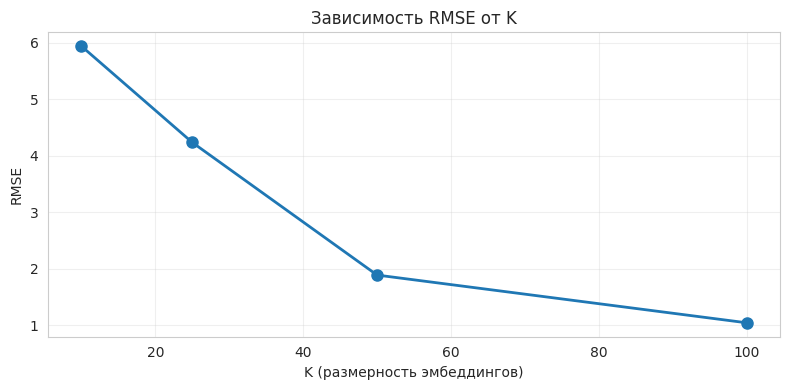

In [19]:
results_k = []

for k in [10, 25, 50, 100]:
    u_in = Input(shape=(1,))
    m_in = Input(shape=(1,))
    u_e  = Flatten()(Embedding(n_users,  k)(u_in))
    m_e  = Flatten()(Embedding(n_movies, k)(m_in))
    dot_ = Dot(axes=1)([u_e, m_e])
    u_b  = Flatten()(Embedding(n_users,  1)(u_in))
    m_b  = Flatten()(Embedding(n_movies, 1)(m_in))
    p    = Add()([dot_, u_b, m_b])
    m    = Model([u_in, m_in], p)
    m.compile(optimizer=Adam(0.001), loss='mse')
    m.fit([X_train[:,0], X_train[:,1]], y_train,
          epochs=30, batch_size=64, validation_split=0.1,
          callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
          verbose=0)
    p_   = m.predict([X_test[:,0], X_test[:,1]], verbose=0).flatten()
    r    = np.sqrt(mean_squared_error(y_test, p_))
    results_k.append({'K': k, 'RMSE': round(r, 4)})
    print(f'K={k:3d}  RMSE={r:.4f}')

df_k = pd.DataFrame(results_k)
plt.figure(figsize=(8, 4))
plt.plot(df_k['K'], df_k['RMSE'], 'o-', linewidth=2, markersize=8)
plt.xlabel('K (размерность эмбеддингов)')
plt.ylabel('RMSE')
plt.title('Зависимость RMSE от K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
print('=== Анализ результатов ===')
print(f'Итоговый RMSE модели (K=50): {rmse:.3f}')
print()
print('Что считать приемлемым:')
print('  Рейтинги сгенерированы с шумом ~0.3, поэтому RMSE < 0.5 — отлично')
print('  RMSE < 1.0 — приемлемо для продакшн-системы')
print()
print('Способы улучшения модели:')
print('  1. Добавить MLP-ветку (NCF — Neural Collaborative Filtering)')
print('  2. Добавить признаки жанра как отдельный эмбеддинг')
print('  3. Учитывать время просмотра (temporal dynamics)')
print('  4. Использовать Attention-механизм поверх эмбеддингов')
print('  5. Применить двустороннее регуляризацию (Dropout + L2)')

=== Анализ результатов ===
Итоговый RMSE модели (K=50): 0.831

Что считать приемлемым:
  Рейтинги сгенерированы с шумом ~0.3, поэтому RMSE < 0.5 — отлично
  RMSE < 1.0 — приемлемо для продакшн-системы

Способы улучшения модели:
  1. Добавить MLP-ветку (NCF — Neural Collaborative Filtering)
  2. Добавить признаки жанра как отдельный эмбеддинг
  3. Учитывать время просмотра (temporal dynamics)
  4. Использовать Attention-механизм поверх эмбеддингов
  5. Применить двустороннее регуляризацию (Dropout + L2)


## Задание 9*. Дополнительно

In [22]:
print('=== Топ-5 без фильтра по жанру ===')
for user in ['Иван', 'Ольга', 'Дмитрий']:
    print(f'\n👤 {user}:')
    print(recommend(user, genre=None, top_n=5).to_string())

=== Топ-5 без фильтра по жанру ===

👤 Иван:
          Фильм      Жанр  Предсказанный рейтинг
1  Pulp Fiction  криминал                   9.01
2         Маска   комедия                   8.95
3       Ведьмак   фэнтези                   8.70
4         Довод    боевик                   8.69
5   Супербратья   комедия                   8.65

👤 Ольга:
                Фильм      Жанр  Предсказанный рейтинг
1               Маска   комедия                   8.94
2               Довод    боевик                   8.83
3   Однажды в Америке  криминал                   8.80
4  Mad Max: Fury Road    боевик                   8.78
5       Крёстный отец  криминал                   8.70

👤 Дмитрий:
               Фильм      Жанр  Предсказанный рейтинг
1              Маска   комедия                   9.29
2  Однажды в Америке  криминал                   9.27
3            Ведьмак   фэнтези                   9.17
4        Супербратья   комедия                   9.11
5              Довод    боевик          

In [23]:
results_loss = []
for loss_fn in ['mse', 'mae']:
    u_in = Input(shape=(1,))
    m_in = Input(shape=(1,))
    u_e  = Flatten()(Embedding(n_users,  50)(u_in))
    m_e  = Flatten()(Embedding(n_movies, 50)(m_in))
    dot_ = Dot(axes=1)([u_e, m_e])
    u_b  = Flatten()(Embedding(n_users,  1)(u_in))
    m_b  = Flatten()(Embedding(n_movies, 1)(m_in))
    p    = Add()([dot_, u_b, m_b])
    m    = Model([u_in, m_in], p)
    m.compile(optimizer=Adam(0.001), loss=loss_fn)
    m.fit([X_train[:,0], X_train[:,1]], y_train,
          epochs=30, batch_size=64, validation_split=0.1,
          callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
          verbose=0)
    p_   = m.predict([X_test[:,0], X_test[:,1]], verbose=0).flatten()
    r    = np.sqrt(mean_squared_error(y_test, p_))
    ma   = np.mean(np.abs(y_test - p_))
    results_loss.append({'Функция потерь': loss_fn.upper(), 'RMSE': round(r,4), 'MAE': round(ma,4)})

print(pd.DataFrame(results_loss).to_string(index=False))

Функция потерь   RMSE    MAE
           MSE 1.7735 1.4589
           MAE 0.9077 0.6361


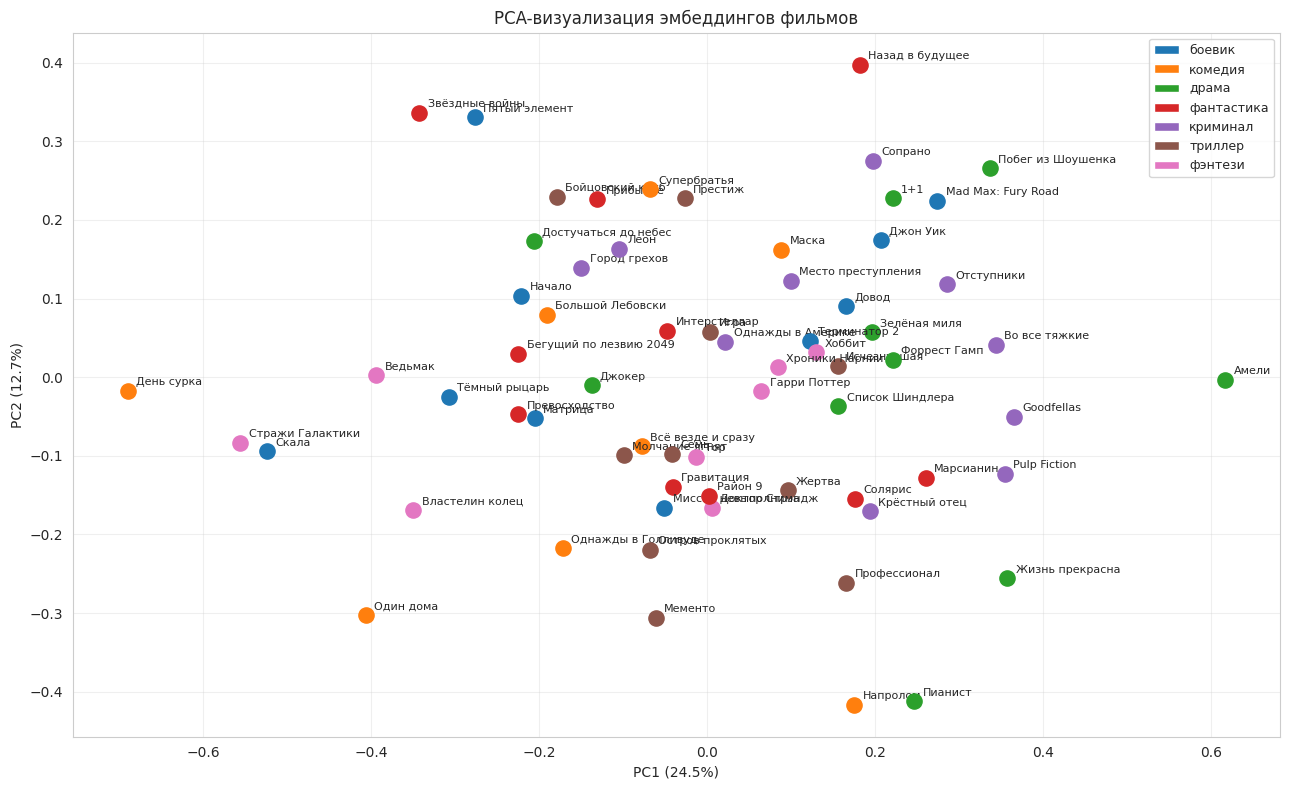

Кластеры по жанрам — фильмы одного жанра должны располагаться близко друг к другу


In [24]:
from sklearn.decomposition import PCA

movie_emb_weights = model.get_layer('movie_emb').get_weights()[0]

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(movie_emb_weights)

genres_list = [movie_genres[i] for i in range(n_movies)]
titles_list = [movie_titles[i] for i in range(n_movies)]
unique_genres = list(set(genres_list))
palette = dict(zip(unique_genres, sns.color_palette('tab10', len(unique_genres))))

plt.figure(figsize=(13, 8))
for i, (x, y_coord) in enumerate(coords):
    genre = genres_list[i]
    plt.scatter(x, y_coord, color=palette[genre], s=120, zorder=3)
    plt.annotate(titles_list[i], (x, y_coord),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in palette.items()]
plt.legend(handles=legend_elements, loc='best', fontsize=9)
plt.title('PCA-визуализация эмбеддингов фильмов')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Кластеры по жанрам — фильмы одного жанра должны располагаться близко друг к другу')